<a href="https://colab.research.google.com/github/tisha076/Campus_companion/blob/main/CareerCompass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q scikit-learn joblib pandas matplotlib numpy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

In [3]:
df = pd.read_csv("career_compass_dataset_v3.csv")

df.head()

,Student_ID,Age,Gender,Semester,GPA,Programming_Skill,Math_Skill,Problem_Solving,Communication_Skill,Leadership,Creativity,Teamwork,English_Proficiency,Projects_Completed,Coding_Contest,Internship,Interest,Preferred_Work,Career
0,1001,25,Female,8,3.57,9,8,7,9,9,9,8.0,9.0,2,No,No,Web Development,Individual,Web Developer
1,1002,26,Female,11,3.09,6,6,7,5,6,5,6.0,6.0,8,Yes,No,Web Development,Team,Web Developer
2,1003,22,Male,2,3.39,7,6,6,7,7,6,7.0,8.0,4,No,No,Web Development,Hybrid,Web Developer
3,1004,18,Female,8,3.59,8,8,8,7,8,7,8.0,9.0,8,No,No,Web Development,Individual,Web Developer
4,1005,18,Male,1,3.41,7,8,7,6,5,7,5.0,6.0,6,No,Yes,Web Development,Hybrid,Web Developer


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           1000 non-null   int64  
 1   Age                  1000 non-null   int64  
 2   Gender               1000 non-null   object 
 3   Semester             1000 non-null   int64  
 4   GPA                  1000 non-null   float64
 5   Programming_Skill    1000 non-null   int64  
 6   Math_Skill           1000 non-null   int64  
 7   Problem_Solving      1000 non-null   int64  
 8   Communication_Skill  1000 non-null   int64  
 9   Leadership           1000 non-null   int64  
 10  Creativity           1000 non-null   int64  
 11  Teamwork             980 non-null    float64
 12  English_Proficiency  980 non-null    float64
 13  Projects_Completed   1000 non-null   int64  
 14  Coding_Contest       1000 non-null   object 
 15  Internship           1000 non-null   ob

In [5]:
df.describe()

,Student_ID,Age,Semester,GPA,Programming_Skill,Math_Skill,Problem_Solving,Communication_Skill,Leadership,Creativity,Teamwork,English_Proficiency,Projects_Completed
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,980.000000,980.000000,1000.000000
mean,1500.500000,22.016000,6.551000,3.42168,7.427000,6.874000,7.156000,6.94000,6.916000,7.111000,6.826531,6.815306,4.316000
std,288.819436,2.584264,3.486769,0.26112,1.610983,1.596456,1.583089,1.44516,1.486995,1.426434,1.380778,1.310588,2.059705
min,1001.000000,18.000000,1.000000,2.72000,2.000000,1.000000,1.000000,3.00000,3.000000,3.000000,2.000000,3.000000,0.000000
25%,1250.750000,20.000000,4.000000,3.24000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.000000,3.000000
50%,1500.500000,22.000000,7.000000,3.43000,8.000000,7.000000,7.000000,7.00000,7.000000,7.000000,7.000000,7.000000,4.000000
75%,1750.250000,24.000000,10.000000,3.61000,9.000000,8.000000,8.000000,8.00000,8.000000,8.000000,8.000000,8.000000,6.000000
max,2000.000000,26.000000,12.000000,4.00000,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000,12.000000


In [6]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Semester,0
GPA,0
Programming_Skill,0
Math_Skill,0
Problem_Solving,0
Communication_Skill,0
Leadership,0


In [7]:
numeric_columns = df.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy="median")

df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

In [8]:
label_encoders = {}

categorical_columns = [
    "Gender",
    "Coding_Contest",
    "Internship",
    "Interest",
    "Preferred_Work",
    "Career"
]

for column in categorical_columns:

    encoder = LabelEncoder()

    df[column] = encoder.fit_transform(df[column])

    label_encoders[column] = encoder

In [9]:
X = df.drop("Career", axis=1)

y = df["Career"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.995


In [12]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 1.0


In [13]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 1.0


In [14]:
print("---------------------")
print("Decision Tree :", accuracy_score(y_test, dt_pred))
print("Random Forest :", accuracy_score(y_test, rf_pred))
print("KNN           :", accuracy_score(y_test, knn_pred))

---------------------
Decision Tree : 0.995
Random Forest : 1.0
KNN           : 1.0


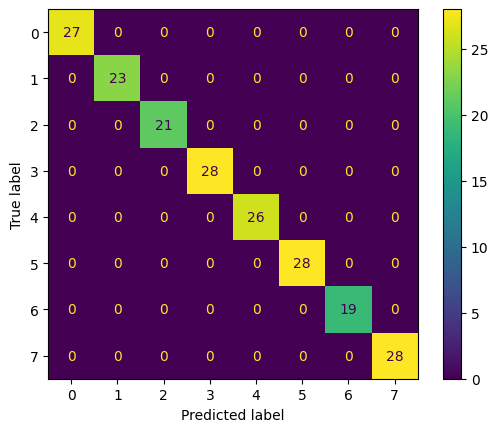

In [15]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

plt.show()

In [16]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        23
           2       1.00      1.00      1.00        21
           3       1.00      1.00      1.00        28
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00        28
           6       1.00      1.00      1.00        19
           7       1.00      1.00      1.00        28

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



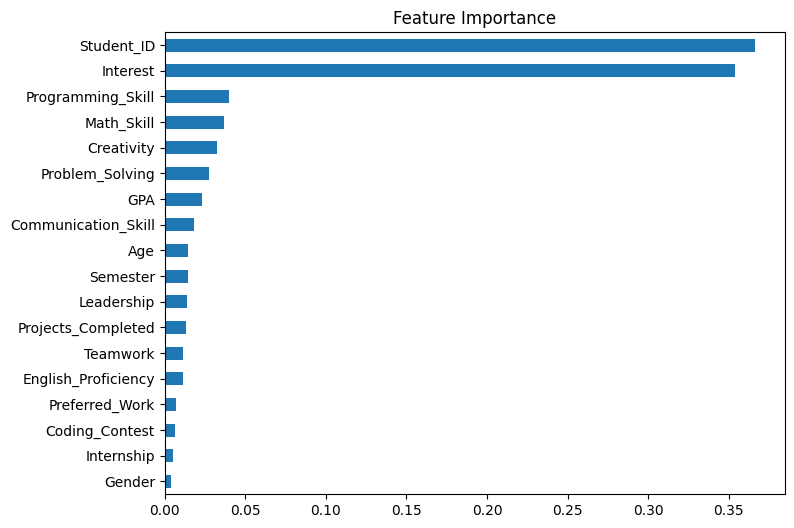

In [17]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance")

plt.show()

In [18]:
joblib.dump(rf, "model.pkl")
joblib.dump(label_encoders, "label_encoder.pkl")

['label_encoder.pkl']

In [19]:
def predict_career(
    age,
    gender,
    semester,
    gpa,
    programming,
    math,
    problem_solving,
    communication,
    leadership,
    creativity,
    teamwork,
    english,
    projects,
    coding_contest,
    internship,
    interest,
    preferred_work
):

    data = pd.DataFrame([{
        "Student_ID": 9999,
        "Age": age,
        "Gender": gender,
        "Semester": semester,
        "GPA": gpa,
        "Programming_Skill": programming,
        "Math_Skill": math,
        "Problem_Solving": problem_solving,
        "Communication_Skill": communication,
        "Leadership": leadership,
        "Creativity": creativity,
        "Teamwork": teamwork,
        "English_Proficiency": english,
        "Projects_Completed": projects,
        "Coding_Contest": coding_contest,
        "Internship": internship,
        "Interest": interest,
        "Preferred_Work": preferred_work
    }])

    # Encode categorical values
    for col in ["Gender", "Coding_Contest", "Internship", "Interest", "Preferred_Work"]:
        data[col] = label_encoders[col].transform(data[col])

    prediction = rf.predict(data)

    career = label_encoders["Career"].inverse_transform(prediction)

    print("Recommended Career:", career[0])

In [20]:
predict_career(
    age=22,
    gender="Male",
    semester=8,
    gpa=3.82,
    programming=9,
    math=9,
    problem_solving=8,
    communication=7,
    leadership=6,
    creativity=6,
    teamwork=8,
    english=8,
    projects=6,
    coding_contest="Yes",
    internship="Yes",
    interest="AI",
    preferred_work="Team"
)

Recommended Career: AI Engineer


In [24]:
data = pd.DataFrame([{
    "Student_ID": 9999,
    "Age": 22,
    "Gender": "Male",
    "Semester": 8,
    "GPA": 3.82,
    "Programming_Skill": 9,
    "Math_Skill": 9,
    "Problem_Solving": 8,
    "Communication_Skill": 7,
    "Leadership": 6,
    "Creativity": 6,
    "Teamwork": 8,
    "English_Proficiency": 8,
    "Projects_Completed": 6,
    "Coding_Contest": "Yes",
    "Internship": "Yes",
    "Interest": "AI",
    "Preferred_Work": "Team"
}])


for col in ["Gender", "Coding_Contest", "Internship", "Interest", "Preferred_Work"]:
    data[col] = label_encoders[col].transform(data[col])

probabilities = rf.predict_proba(data)[0]

top3 = np.argsort(probabilities)[::-1][:3]

for index in top3:

    career = label_encoders["Career"].inverse_transform([index])[0]

    confidence = probabilities[index] * 100

    print(f"{career} : {confidence:.2f}%")

AI Engineer : 41.00%
Cloud Engineer : 24.50%
Game Developer : 18.00%


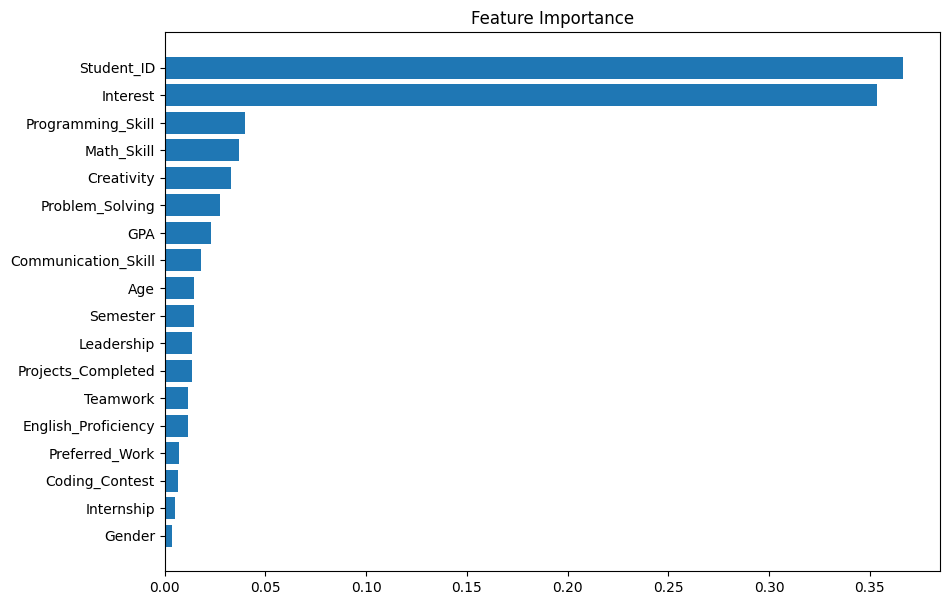

In [25]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,7))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.show()

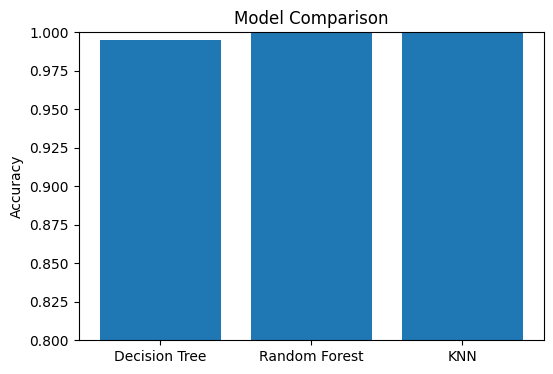

In [26]:
models = ["Decision Tree","Random Forest","KNN"]

accuracy = [
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, knn_pred)
]

plt.figure(figsize=(6,4))

plt.bar(models, accuracy)

plt.ylim(0.8,1)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()